# Employee Data Analysis and Classification

This notebook performs a machine learning analysis on the employee dataset to predict the salary level (`low`, `medium`, or `high`) based on other attributes. The analysis includes data visualization, pipeline creation for preprocessing and modeling, and evaluation of various classification models using 10-fold cross-validation.

## 1. Setup and Data Loading

First, we import the necessary libraries and load the dataset.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Load the dataset
try:
    df = pd.read_csv('employees.csv')
except FileNotFoundError:
    raise FileNotFoundError('employees.csv not found. Place it in the same folder as this notebook.')

# Note: ~20% of rows are exact duplicates, which can inflate CV scores.
# Set to True to remove them.
DROP_DUPLICATES = False
if DROP_DUPLICATES:
    df = df.drop_duplicates().reset_index(drop=True)

print('Duplicate rows:', df.duplicated().sum())
print('Shape:', df.shape)
df.info()
print('\nSalary distribution:')
print(df['salary'].value_counts(normalize=True).round(3))
print('\nHead:')
print(df.head())

Duplicate rows: 3008
Shape: (14999, 10)
<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB

Salary distribution:
salary
low       0.488
medium    0.430
high      0.082
Name: proportion, dtype: float64

Head:
   satisfactoryLevel  lastEvaluation  numberOfProjects  avgMont

## 2. Exploratory Data Visualization

A boxplot is created to visualize the distribution of numerical features across the different salary categories (`low`, `medium`, `high`). This helps us understand if there are noticeable differences in these features between the salary groups.

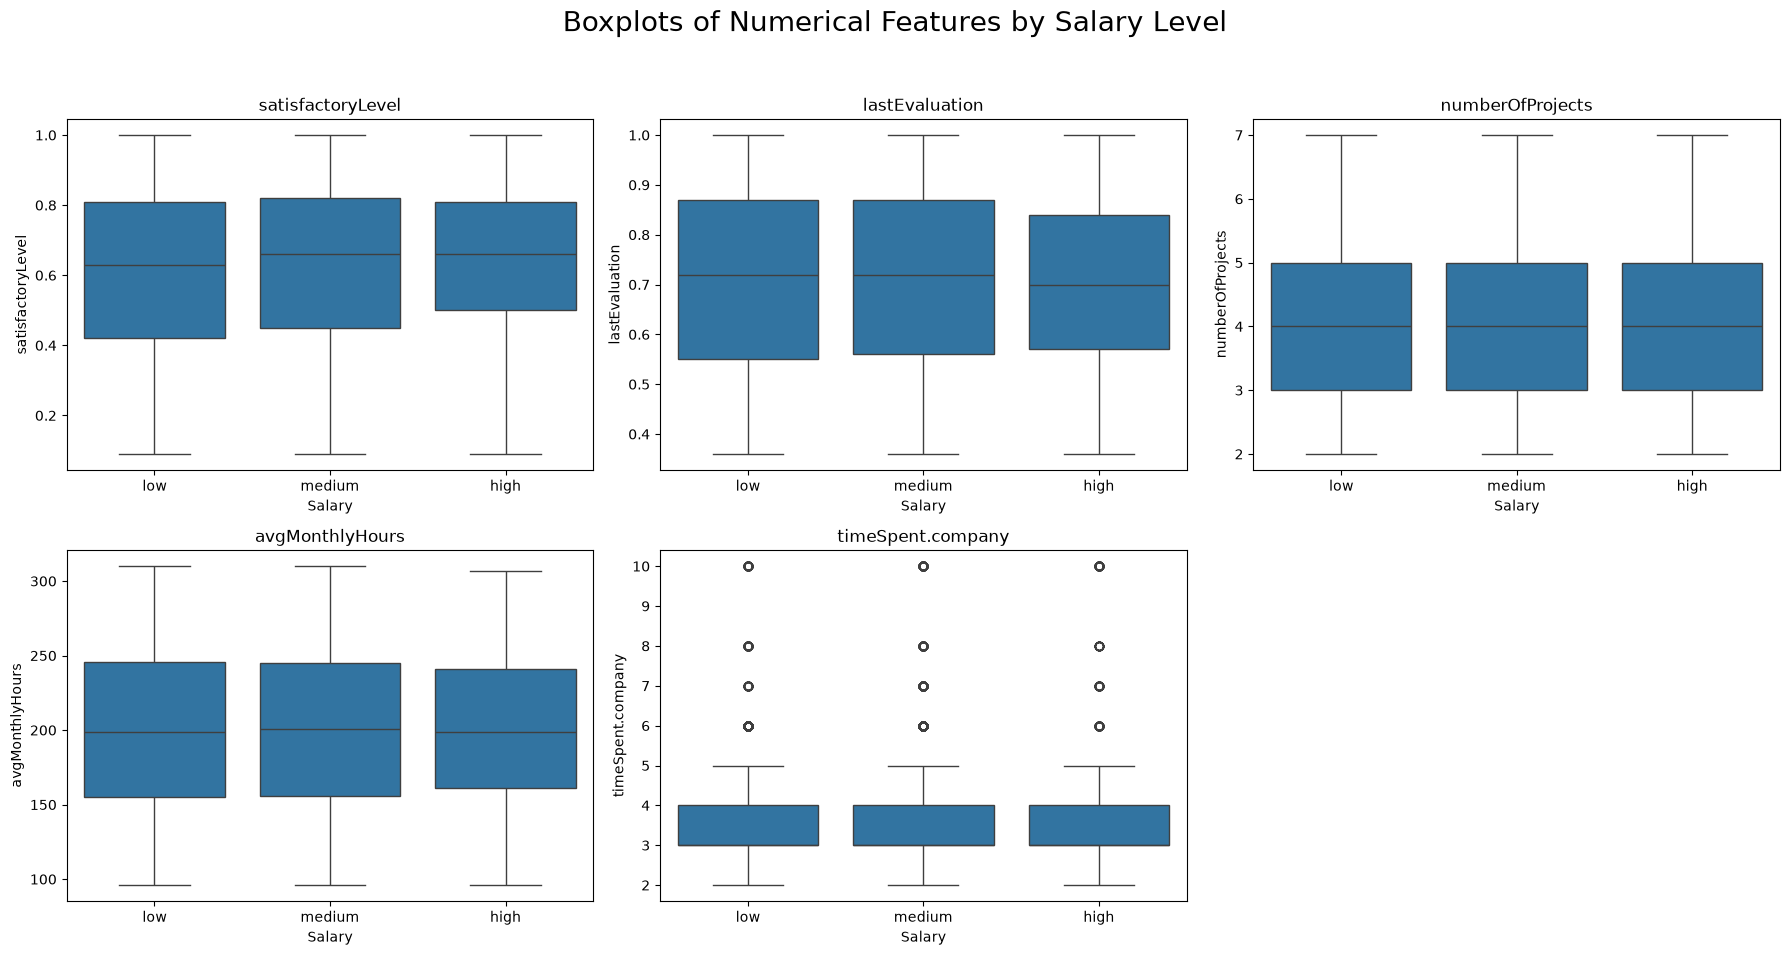

In [2]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()

# Skip binary columns (workAccident, left, promotionInLast5years): boxplots aren't informative
plot_features = [f for f in numerical_features if df[f].nunique() > 2]

n_cols = 3
n_rows = int(np.ceil(len(plot_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.suptitle('Boxplots of Numerical Features by Salary Level', fontsize=20)
axes = axes.flatten()

for ax, feature in zip(axes, plot_features):
    sns.boxplot(x='salary', y=feature, data=df, ax=ax, order=['low', 'medium', 'high'])
    ax.set_title(feature)
    ax.set_xlabel('Salary')
    ax.set_ylabel(feature)

# Hide any unused panels
for ax in axes[len(plot_features):]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 3. Preprocessing and Model Pipelines

We set up pipelines to automate the preprocessing and modeling steps. The `ColumnTransformer` applies `StandardScaler` to numerical features and `OneHotEncoder` to categorical features. Then, each classifier is combined with this preprocessor in a `Pipeline`.

In [3]:
# Define features (X) and target (y)
X = df.drop('salary', axis=1)
y = df['salary']

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

# Preprocessor (every column is handled, so no 'remainder' needed)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Neural Network': MLPClassifier(max_iter=1000, random_state=42)
}

pipelines = {
    name: Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    for name, clf in classifiers.items()
}

# Note: KDE is a density estimator, not a standard classifier, so it is excluded.

## 4. Model Evaluation with 10-Fold Cross-Validation

We will use `StratifiedKFold` with 10 splits to ensure the class distribution is maintained in each fold. For each model, we will calculate accuracy, precision, recall, and F-measure.

In [4]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'Accuracy': 'accuracy',
    'Precision': 'precision_weighted',
    'Recall': 'recall_weighted',
    'F1-Score': 'f1_weighted',
    'Macro F1': 'f1_macro'   # shows performance on the rare 'high' class too
}

rows = []
for name, pipeline in pipelines.items():
    print(f'Evaluating {name}...')
    scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring, n_jobs=-1)
    row = {'Model': name}
    for label in scoring:
        row[label] = scores[f'test_{label}'].mean()
    rows.append(row)

results = pd.DataFrame(rows)
print('\n\nClassification Results (10-fold CV):')
print(results.set_index('Model').round(4))

Evaluating Logistic Regression...
Evaluating Naive Bayes...
Evaluating K-Nearest Neighbors...
Evaluating SVM...
Evaluating Decision Tree...
Evaluating Neural Network...


Classification Results (10-fold CV):
                     Accuracy  Precision  Recall  F1-Score  Macro F1
Model                                                               
Logistic Regression    0.4994     0.4864  0.4994    0.4623    0.3870
Naive Bayes            0.4836     0.4685  0.4836    0.4095    0.3511
K-Nearest Neighbors    0.5102     0.5021  0.5102    0.5043    0.4163
SVM                    0.5130     0.5199  0.5130    0.4775    0.3699
Decision Tree          0.6128     0.6154  0.6128    0.6139    0.5527
Neural Network         0.5148     0.5124  0.5148    0.5014    0.4136
